# Lëk — Food Price Inflation Forecasting (v2: change-based target)

Predicts South Sudan's food price index **one month ahead**. Compares five models:
Linear Regression, ARIMA, Random Forest, XGBoost, and an LSTM.

**v2 reframing — why this notebook predicts CHANGE, not LEVEL.**
The food price index trends steeply upward, so in the v1 (level-based) notebook
**100% of the test window sat above the entire training range**. Tree models and the
LSTM cannot extrapolate beyond their training range, so they failed badly (negative
R²); only ARIMA worked, because its differencing models change. But ARIMA is
univariate and ignores our conflict, oil, and exchange-rate features — defeating the
project's purpose.

**The fix:** all models now predict the **month-over-month log-change**
`y = ln(next_index) − ln(this_index)`, using the full 47-feature set. The change
target is stationary (test values fall *within* the training range), so every model
can compete fairly. We then **reconstruct the level** (`level = this_index · e^ŷ`) and
score RMSE/MAE/MAPE/R² on the level — directly comparable to v1 — and also report
change-space metrics.

### v1 (level-based) results — kept for the before/after comparison

These are the previous results when models predicted the **level** directly. Four of
five models had negative R² because they could not extrapolate the upward trend.

| Model | RMSE | MAE | MAPE % | R² |
|---|---|---|---|---|
| LinearRegression | 10.042 | 9.015 | 21.37 | −7.419 |
| ARIMA | 1.197 | 1.000 | 2.39 | 0.880 |
| RandomForest | 14.292 | 13.722 | 32.39 | −16.053 |
| XGBoost | 33.499 | 33.320 | 79.94 | −92.685 |
| LSTM | 40.141 | 40.005 | 96.16 | −133.517 |

The comparison section below prints the **v2 (change-based)** results next to these.

## 1. Setup
Imports, reproducibility seeds (42 everywhere), library versions.

In [1]:
import os, json, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
random.seed(SEED)
np.random.seed(SEED)

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels
from statsmodels.tsa.arima.model import ARIMA

import xgboost as xgb
from xgboost import XGBRegressor

import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("statsmodels ", statsmodels.__version__)
print("xgboost     ", xgb.__version__)
print("tensorflow  ", tf.__version__)

pandas       3.0.3
numpy        2.4.6
scikit-learn 1.9.0
statsmodels  0.14.6
xgboost      3.2.0
tensorflow   2.21.0


In [2]:
HERE = Path.cwd().resolve()
root = HERE
while not (root / "ml-service").exists() and root != root.parent:
    root = root.parent
assert (root / "ml-service").exists(), "Could not locate repo root (no ml-service/ found)"

DATA_DIR   = root / "training" / "data"
RAW        = DATA_DIR / "raw"
MANUAL     = DATA_DIR / "manual"
PROCESSED  = DATA_DIR / "processed"
MODELS_DIR = root / "ml-service" / "models"
PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("repo root  :", root)

repo root  : /Users/apple/Documents/capstone-project/Lek/lek


## 2. Data Loading
Load all 7 datasets. The 250 MB UCDP global file is filtered to
`country IN ('South Sudan','Sudan')` as it is read (chunked).

In [3]:
def summarize(name, df):
    print(f"\n{'='*60}\n{name}: shape={df.shape}\n{'='*60}")
    miss = df.isna().mean().sort_values(ascending=False)
    print("top missing-value fractions:")
    print(miss.head(5).to_string())
    return df

In [4]:
rtfp = pd.read_csv(RAW / "rtfp_food_prices.csv", low_memory=False)
summarize("RTFP food prices", rtfp)
rtfp.head(2)


RTFP food prices: shape=(9320, 123)
top missing-value fractions:
cassava       0.956652
millet        0.922532
sesame        0.884764
groundnuts    0.862339
maize_meal    0.838412


,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_wheat_flour,c_wheat_flour,inflation_wheat_flour,trust_wheat_flour,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-01-01,2007,...,1.43,1.55,NaN,9.3,0.01,0.01,0.01,0.01,NaN,8.8
1,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-02-01,2007,...,1.49,1.50,NaN,9.3,0.01,0.01,0.01,0.01,NaN,8.8


In [5]:
rtfx = pd.read_csv(RAW / "rtfx_exchange_rate.csv", low_memory=False)
summarize("RTFX exchange rate", rtfx)


RTFX exchange rate: shape=(9320, 33)
top missing-value fractions:
trust_exchange_rate_unofficial                          1.000000
milling_cost_sorghum                                    0.838197
wage_non_qualified_labour_non_agricultural              0.823820
inflation_wage_non_qualified_labour_non_agricultural    0.051502
inflation_exchange_rate_unofficial                      0.051502


,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_milling_cost_sorghum,c_milling_cost_sorghum,inflation_milling_cost_sorghum,trust_milling_cost_sorghum,o_wage_non_qualified_labour_non_agricultural,h_wage_non_qualified_labour_non_agricultural,l_wage_non_qualified_labour_non_agricultural,c_wage_non_qualified_labour_non_agricultural,inflation_wage_non_qualified_labour_non_agricultural,trust_wage_non_qualified_labour_non_agricultural
0,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-01-01,2007,...,0.46,0.49,NaN,8.9,9.45,10.61,9.00,9.82,NaN,8.3
1,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-02-01,2007,...,0.48,0.48,NaN,8.9,10.19,11.02,9.35,9.73,NaN,8.3
2,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-03-01,2007,...,0.46,0.50,NaN,8.9,10.05,10.75,9.35,9.87,NaN,8.3
3,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-04-01,2007,...,0.48,0.50,NaN,8.9,10.19,10.89,9.49,9.94,NaN,8.3
4,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-05-01,2007,...,0.49,0.52,NaN,8.9,10.25,10.89,9.61,10.21,NaN,8.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9315,SSD,South Sudan,Market Average,Market Average,Market Average,NaN,NaN,gid_ssd_national_average,2026-01-01,2026,...,2937.50,3000.00,50.00,10.0,26585.64,30386.42,18420.16,18420.16,20.43,9.8
9316,SSD,South Sudan,Market Average,Market Average,Market Average,NaN,NaN,gid_ssd_national_average,2026-02-01,2026,...,2936.49,3000.00,50.00,9.9,18968.46,22032.19,13572.09,13572.09,-22.41,9.8
9317,SSD,South Sudan,Market Average,Market Average,Market Average,NaN,NaN,gid_ssd_national_average,2026-03-01,2026,...,2936.77,3000.00,50.00,9.9,13635.68,15990.88,10000.00,10000.00,-42.48,9.8
9318,SSD,South Sudan,Market Average,Market Average,Market Average,NaN,NaN,gid_ssd_national_average,2026-04-01,2026,...,2936.68,3000.00,30.56,9.9,9859.95,14305.41,8172.37,14305.41,-19.21,9.8


In [6]:
eia_raw = pd.read_csv(RAW / "eia_oil_production_monthly.csv", skiprows=1, low_memory=False)
print("EIA raw (wide):", eia_raw.shape)

EIA raw (wide): (8, 555)


In [7]:
ucdp_cols = ["year", "country", "date_start", "best", "type_of_violence", "deaths_civilians"]
parts = []
for chunk in pd.read_csv(RAW / "ucdp_ged.csv", usecols=ucdp_cols, chunksize=200_000, low_memory=False):
    parts.append(chunk[chunk["country"].isin(["South Sudan", "Sudan"])])
ucdp = pd.concat(parts, ignore_index=True)
print("UCDP filtered:", ucdp.shape)
print(ucdp["country"].value_counts().to_string())

UCDP filtered: (5557, 6)
country
Sudan          4556
South Sudan    1001


In [8]:
cpi_raw = pd.read_csv(RAW / "wb_national_cpi.csv", skiprows=4, low_memory=False)
pipeline = pd.read_csv(MANUAL / "pipeline_status.csv")
seasonal = pd.read_csv(MANUAL / "seasonal_calendar.csv")
print("CPI:", cpi_raw.shape, "| pipeline:", pipeline.shape, "| seasonal:", seasonal.shape)

CPI: (266, 71) | pipeline: (233, 2) | seasonal: (12, 3)


## 3. Cleaning and Monthly Aggregation
Each source is reduced to one row per calendar month (`date` = first of month).

In [9]:
COMMODITIES = ["beans","cassava","groundnuts","livestockgoat_male","livestocksheep_male",
               "maize","maize_meal","millet","oil","salt","sesame","sorghum","sugar","wheat_flour"]

def to_month(df):
    return pd.to_datetime(df["price_date"]).dt.to_period("M").dt.to_timestamp()

rtfp = rtfp.copy(); rtfp["date"] = to_month(rtfp)
commodity_close = [f"c_{c}" for c in COMMODITIES]
rtfp_cols = ["c_food_price_index", "inflation_food_price_index"] + commodity_close
rtfp_m = rtfp.groupby("date")[rtfp_cols].mean().reset_index()
rtfp_m[rtfp_cols] = rtfp_m[rtfp_cols].ffill()

rtfx = rtfx.copy(); rtfx["date"] = to_month(rtfx)
rtfx_m = rtfx.groupby("date")["c_exchange_rate_unofficial"].mean().reset_index()
rtfx_m = rtfx_m.rename(columns={"c_exchange_rate_unofficial": "exchange_rate"})
rtfx_m["exchange_rate"] = rtfx_m["exchange_rate"].ffill()
print("RTFP monthly:", rtfp_m.shape, "| RTFX monthly:", rtfx_m.shape)

RTFP monthly: (233, 17) | RTFX monthly: (233, 2)


In [10]:
SERIES_API = "INTL.53-1-SSD-TBPD.M"
row = eia_raw[eia_raw.iloc[:, 0] == SERIES_API]
month_cols = [c for c in eia_raw.columns if c not in ("API", "Unnamed: 1")]
oil = row[month_cols].T.reset_index()
oil.columns = ["month_label", "oil_production"]
oil["date"] = pd.to_datetime(oil["month_label"], format="%b %Y").dt.to_period("M").dt.to_timestamp()
oil["oil_production"] = pd.to_numeric(oil["oil_production"].replace({"--": np.nan, "": np.nan}), errors="coerce")
oil_m = oil[["date", "oil_production"]].sort_values("date").reset_index(drop=True)

ucdp = ucdp.copy()
ucdp["date"] = pd.to_datetime(ucdp["date_start"], errors="coerce").dt.to_period("M").dt.to_timestamp()
ucdp = ucdp.dropna(subset=["date"])
agg = ucdp.groupby(["country", "date"]).agg(events=("best", "size"), deaths=("best", "sum")).reset_index()
piv = agg.pivot(index="date", columns="country", values=["events", "deaths"])
piv.columns = [f"{m}_{'ssd' if c=='South Sudan' else 'sdn'}" for m, c in piv.columns]
piv = piv.rename(columns={"events_ssd": "conflict_events_ssd", "deaths_ssd": "conflict_deaths_ssd",
                          "events_sdn": "conflict_events_sdn", "deaths_sdn": "conflict_deaths_sdn"})
conflict_m = piv.reset_index()

year_cols = [c for c in cpi_raw.columns if str(c).isdigit()]
ssd_cpi = cpi_raw[cpi_raw["Country Code"] == "SSD"]
cpi_long = ssd_cpi[year_cols].T.reset_index()
cpi_long.columns = ["year", "national_cpi"]
cpi_long["year"] = cpi_long["year"].astype(int)
cpi_long["national_cpi"] = pd.to_numeric(cpi_long["national_cpi"], errors="coerce")
cpi_long = cpi_long.dropna(subset=["national_cpi"])

pipeline = pipeline.copy()
pipeline["date"] = pd.to_datetime(pipeline["date"]).dt.to_period("M").dt.to_timestamp()
pipeline_m = pipeline.set_index("date")["pipeline_flowing"].resample("MS").last().ffill().reset_index()
print("oil:", oil_m.shape, "| conflict:", conflict_m.shape, "| cpi pts:", len(cpi_long))

oil: (553, 2) | conflict: (418, 5) | cpi pts: 16


## 4. Master Monthly Table + Target Reframing
Join all 7 sources onto a **Jan 2007 → May 2026** monthly spine, then define:

- `this_month_index` — the current month's index (known at prediction time; used to
  reconstruct the level later).
- `next_month_index` — next month's index (the true LEVEL we ultimately score on).
- **`y_log_change = ln(next_month_index) − ln(this_month_index)`** — the model target.

Why **log-difference** and not raw % change: the index spans 0.01 → ~47, and early
values near 0.01 make raw percentage change explode (dividing by ~0.01). The
log-difference is symmetric and numerically stable across that whole range, and all
index values are strictly positive so the log is always defined.

In [11]:
spine = pd.DataFrame({"date": pd.date_range("2007-01-01", "2026-05-01", freq="MS")})
m = (spine.merge(rtfp_m, on="date", how="left").merge(rtfx_m, on="date", how="left")
          .merge(oil_m, on="date", how="left").merge(conflict_m, on="date", how="left"))
m["year"] = m["date"].dt.year
m["month"] = m["date"].dt.month
m = m.merge(cpi_long, on="year", how="left").merge(seasonal, on="month", how="left").merge(pipeline_m, on="date", how="left")

conflict_cols = ["conflict_events_ssd","conflict_deaths_ssd","conflict_events_sdn","conflict_deaths_sdn"]
m[conflict_cols] = m[conflict_cols].fillna(0.0)
m["oil_production"] = m["oil_production"].ffill().fillna(0.0)
m["national_cpi"] = m["national_cpi"].ffill().bfill()
m["pipeline_flowing"] = m["pipeline_flowing"].ffill().fillna(1).astype(int)

m = m.sort_values("date").reset_index(drop=True)
m["this_month_index"] = m["c_food_price_index"]
m["next_month_index"] = m["c_food_price_index"].shift(-1)
m["y_next_month"] = m["next_month_index"]                       # LEVEL (for evaluation)
m["y_log_change"] = np.log(m["next_month_index"]) - np.log(m["this_month_index"])  # CHANGE (target)

master = m.dropna(subset=["next_month_index"]).reset_index(drop=True)
master.to_csv(PROCESSED / "master_monthly.csv", index=False)
print("master:", master.shape, "|", master["date"].min().date(), "->", master["date"].max().date())
print("y_log_change  describe:\n", master["y_log_change"].describe().round(4).to_string())

master: (232, 33) | 2007-01-01 -> 2026-04-01
y_log_change  describe:
 count    232.0000
mean       0.0364
std        0.0695
min       -0.2513
25%        0.0000
50%        0.0348
75%        0.0716
max        0.2570


In [12]:
key_cols = ["c_food_price_index", "exchange_rate", "y_log_change"]
miss = master[key_cols].isna().mean()
assert (miss < 0.05).all(), f"key columns exceed 5% missing: {miss.to_dict()}"
print("OK: key columns < 5% missing")

OK: key columns < 5% missing


## 5. Feature Engineering (47 features)
Lags & rolling means of the index, exchange-rate lags, oil lag, **lagged** conflict
signals (SS + Sudan), pipeline flag, seasonal calendar, month-of-year one-hot, and
the 14 commodity close prices. The target is the **log-change**; `this_month_index`
and `next_month_index` are carried through for reconstruction and scoring (they are
**not** features — `next_month_index` would leak the future).

In [13]:
f = master.copy()
for lag in [1, 3, 6, 12]:
    f[f"fpi_lag{lag}"] = f["c_food_price_index"].shift(lag)
f["fpi_roll3"] = f["c_food_price_index"].rolling(3).mean()
f["fpi_roll6"] = f["c_food_price_index"].rolling(6).mean()
for lag in [1, 3]:
    f[f"fx_lag{lag}"] = f["exchange_rate"].shift(lag)
f["oil_lag1"] = f["oil_production"].shift(1)
for c in conflict_cols:
    f[f"{c}_lag1"] = f[c].shift(1)

# --- v2-tuned: new engineered features (all from PAST data only — no leakage) ---
f["fpi_vol3"]  = f["c_food_price_index"].rolling(3).std()        # 3-month volatility
f["fpi_vol6"]  = f["c_food_price_index"].rolling(6).std()        # 6-month volatility
f["fpi_roll12"] = f["c_food_price_index"].rolling(12).mean()     # 12-month rolling mean
f["fpi_momentum"] = f["c_food_price_index"].diff().diff()        # 2nd difference (acceleration)
f["conflict_x_pipeline"] = f["conflict_events_ssd_lag1"] * f["pipeline_flowing"]  # conflict worse when pipeline down
f["fx_x_oil"] = f["fx_lag1"] * f["oil_lag1"]                     # currency pressure x oil revenue

season_map = {s: i for i, s in enumerate(sorted(f["season"].dropna().unique()))}
f["season_ord"] = f["season"].map(season_map)
f["is_lean_season"] = f["is_lean_season"].astype(int)
month_oh = pd.get_dummies(f["month"], prefix="m").astype(int)
f = pd.concat([f, month_oh], axis=1)

f = f.dropna().reset_index(drop=True)

NEW_FEATURES = ["fpi_vol3", "fpi_vol6", "fpi_roll12", "fpi_momentum",
                "conflict_x_pipeline", "fx_x_oil"]
FEATURES = (["c_food_price_index", "inflation_food_price_index"]
            + [f"c_{c}" for c in COMMODITIES]
            + ["exchange_rate", "oil_production", "national_cpi", "pipeline_flowing",
               "is_lean_season", "season_ord"]
            + [f"fpi_lag{l}" for l in [1,3,6,12]] + ["fpi_roll3","fpi_roll6"]
            + ["fx_lag1","fx_lag3","oil_lag1"]
            + [f"{c}_lag1" for c in conflict_cols]
            + NEW_FEATURES
            + list(month_oh.columns))
TARGET = "y_log_change"
assert "next_month_index" not in FEATURES and "y_log_change" not in FEATURES
print("feature matrix:", f[FEATURES].shape, "| n_features:", len(FEATURES))
print("new features added:", NEW_FEATURES)

feature matrix: (220, 53) | n_features: 53
new features added: ['fpi_vol3', 'fpi_vol6', 'fpi_roll12', 'fpi_momentum', 'conflict_x_pipeline', 'fx_x_oil']


## 5.5 Data Visualization and Data Engineering
The target trajectory, the new change-target distribution, a feature–target
correlation heatmap, and seasonality.

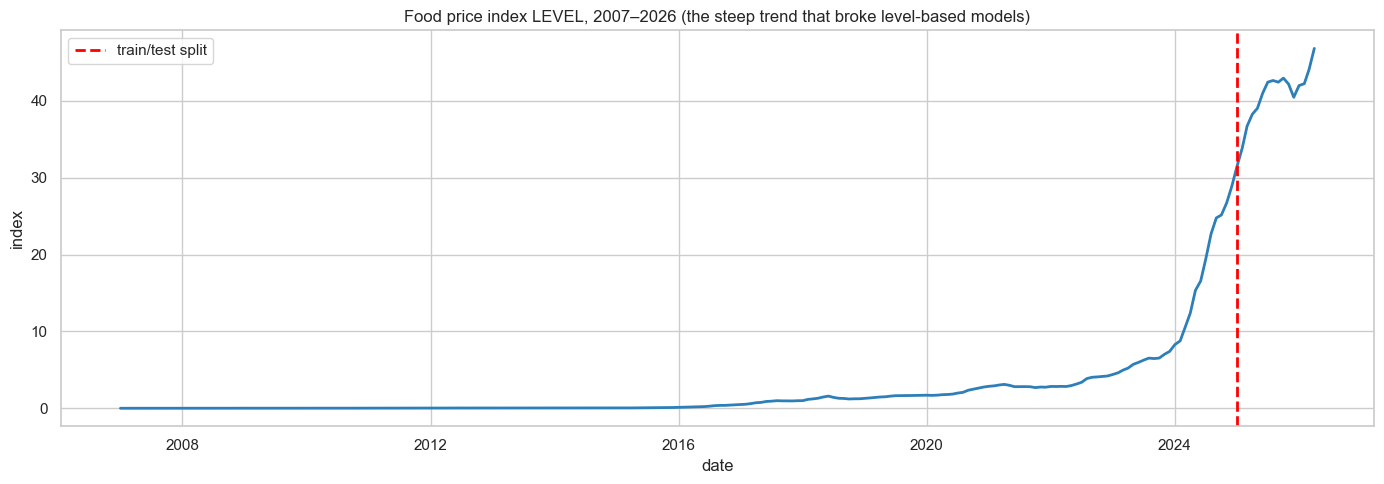

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(master["date"], master["c_food_price_index"], color="#2c7fb8", lw=2)
ax.axvline(pd.Timestamp("2025-01-01"), color="red", ls="--", lw=2, label="train/test split")
ax.set_title("Food price index LEVEL, 2007–2026 (the steep trend that broke level-based models)")
ax.set_xlabel("date"); ax.set_ylabel("index"); ax.legend(); plt.tight_layout(); plt.show()

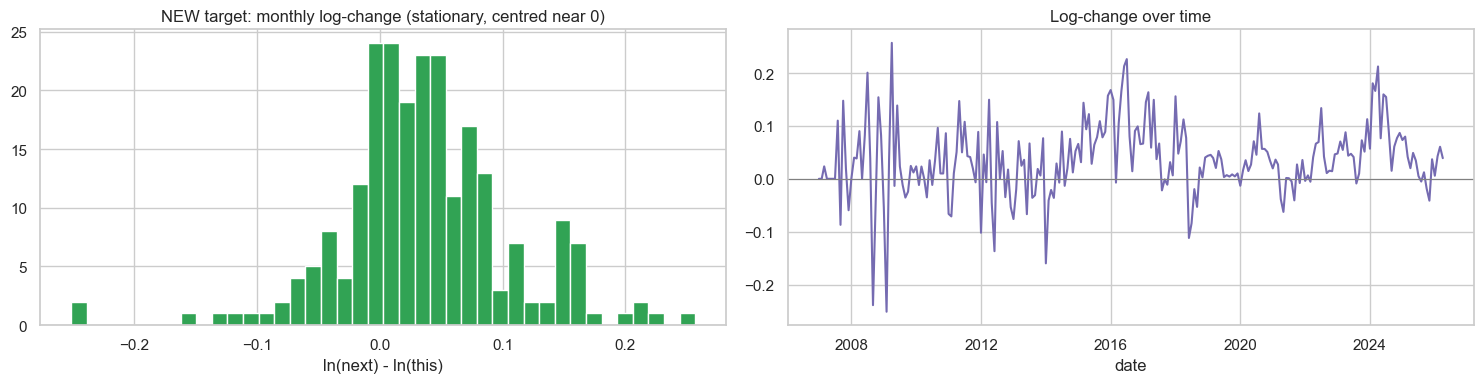

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(master["y_log_change"], bins=40, color="#31a354", edgecolor="white")
ax[0].set_title("NEW target: monthly log-change (stationary, centred near 0)")
ax[0].set_xlabel("ln(next) - ln(this)")
ax[1].plot(master["date"], master["y_log_change"], color="#756bb1")
ax[1].axhline(0, color="grey", lw=0.8); ax[1].set_title("Log-change over time"); ax[1].set_xlabel("date")
plt.tight_layout(); plt.show()

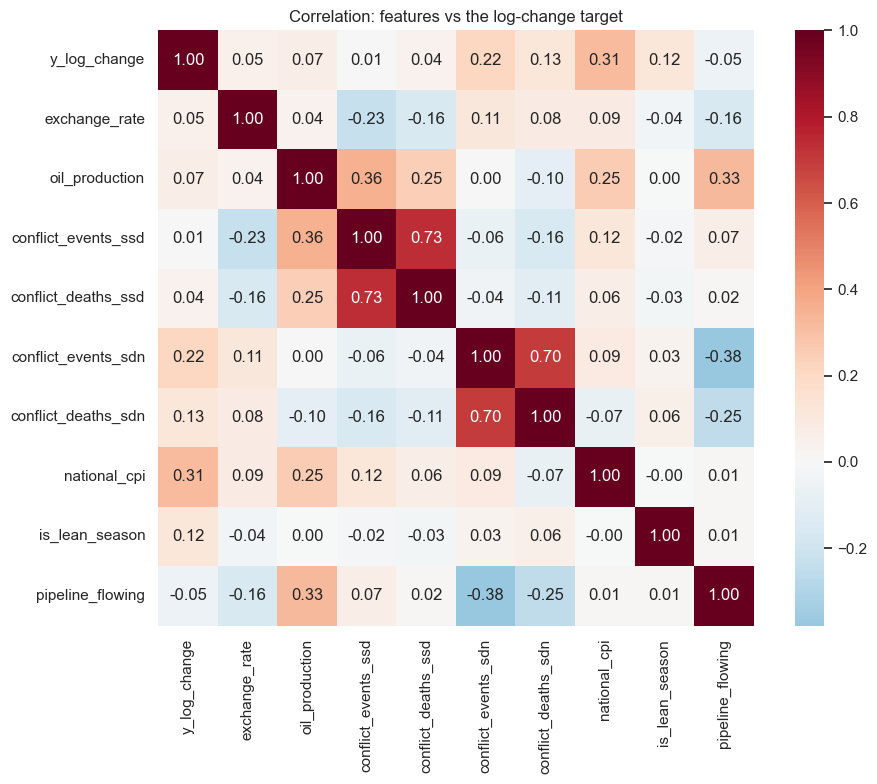

In [16]:
corr_cols = ["y_log_change", "exchange_rate", "oil_production",
             "conflict_events_ssd", "conflict_deaths_ssd", "conflict_events_sdn",
             "conflict_deaths_sdn", "national_cpi", "is_lean_season", "pipeline_flowing"]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(f[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation: features vs the log-change target"); plt.tight_layout(); plt.show()

## 6. Train / Test Split + Metric Helpers
Train ≤ Dec 2024; test Jan 2025 → May 2026. Models predict the **log-change**; we
reconstruct the **level** as `this_index · e^ŷ` and score on it. We report both
**level-space** (comparable to v1) and **change-space** metrics.

In [17]:
split_date = pd.Timestamp("2025-01-01")
tr = f["date"] < split_date
te = f["date"] >= split_date

X_train, X_test = f.loc[tr, FEATURES].values, f.loc[te, FEATURES].values
y_train, y_test = f.loc[tr, TARGET].values, f.loc[te, TARGET].values          # log-change
this_test = f.loc[te, "this_month_index"].values                              # for reconstruction
level_true = f.loc[te, "next_month_index"].values                             # true LEVEL
dates_test = f.loc[te, "date"].values
dates_train = f.loc[tr, "date"].values

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
tscv = TimeSeriesSplit(n_splits=5)
print("train:", X_train.shape, "| test:", X_test.shape)
print("test:", pd.to_datetime(dates_test).min().date(), "->", pd.to_datetime(dates_test).max().date())

train: (204, 53) | test: (16, 53)
test: 2025-01-01 -> 2026-04-01


In [18]:
def recon_level(this_idx, pred_log_change):
    """Reconstruct the LEVEL from a predicted log-change: level = this * exp(change)."""
    return np.asarray(this_idx, float) * np.exp(np.asarray(pred_log_change, float))

def level_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true != 0
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "MAPE": float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100),
            "R2":   float(r2_score(y_true, y_pred))}

def change_metrics(y_true, y_pred):
    """Change-space (on the log-change target). MAPE masked where |actual| < 0.01."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.abs(y_true) >= 0.01
    mape = float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100) if mask.sum() else float("nan")
    return {"R2": float(r2_score(y_true, y_pred)), "MAPE": mape,
            "MAE": float(mean_absolute_error(y_true, y_pred))}

results = {}          # name -> {"level": {...}, "change": {...}}
pred_levels = {}      # name -> reconstructed level array (test)
pred_changes = {}     # name -> predicted log-change array (test)

def record(name, pred_change):
    pred_change = np.asarray(pred_change, float)
    lvl = recon_level(this_test, pred_change)
    results[name] = {"level": level_metrics(level_true, lvl),
                     "change": change_metrics(y_test, pred_change)}
    pred_levels[name] = lvl
    pred_changes[name] = pred_change
    print(f"{name:18s} LEVEL  R2={results[name]['level']['R2']:.3f} "
          f"MAPE={results[name]['level']['MAPE']:.2f}  |  CHANGE R2={results[name]['change']['R2']:.3f}")

## 7. Model 1 — Linear Regression (predicts log-change)

In [19]:
lin = LinearRegression().fit(X_train_s, y_train)
record("LinearRegression", lin.predict(X_test_s))

LinearRegression   LEVEL  R2=-25.935 MAPE=32.84  |  CHANGE R2=-118.153


## 8. Model 2 — ARIMA (univariate baseline)
ARIMA stays univariate on the index series. Its `d=1` differencing already models
*change*, so we let it forecast the **level** directly (rolling one-step over the test
window) — that is the natural, fair form of an ARIMA next-month prediction. Its
change-space numbers are derived from that level forecast as `ln(pred)−ln(this)`.
This keeps ARIMA as the honest univariate benchmark the multivariate models must beat.

In [20]:
fpi = f.set_index("date")["c_food_price_index"].asfreq("MS")
fpi_train = fpi[fpi.index < split_date]
best_aic, best_order = np.inf, None
for p in [0,1,2]:
    for d in [0,1]:
        for q in [0,1,2]:
            try:
                res = ARIMA(fpi_train, order=(p,d,q)).fit()
                if res.aic < best_aic: best_aic, best_order = res.aic, (p,d,q)
            except Exception: continue
print("best ARIMA order:", best_order, "AIC=%.1f" % best_aic)

test_target_dates = pd.to_datetime(dates_test) + pd.offsets.MonthBegin(1)
history = list(fpi[fpi.index <= pd.to_datetime(dates_test).min()].values)
arima_level = []
for tgt in test_target_dates:
    fit = ARIMA(history, order=best_order).fit()
    arima_level.append(float(np.asarray(fit.forecast(1)).ravel()[0]))
    history.append(float(fpi.get(tgt, history[-1])))
arima_level = np.array(arima_level)
# ARIMA recorded directly on the level; change-space derived from the level forecast.
arima_change = np.log(arima_level) - np.log(this_test)
results["ARIMA"] = {"level": level_metrics(level_true, arima_level),
                    "change": change_metrics(y_test, arima_change)}
pred_levels["ARIMA"], pred_changes["ARIMA"] = arima_level, arima_change
print("ARIMA              LEVEL  R2=%.3f MAPE=%.2f" % (results['ARIMA']['level']['R2'], results['ARIMA']['level']['MAPE']))

best ARIMA order: (1, 1, 2) AIC=36.0


ARIMA              LEVEL  R2=0.880 MAPE=2.39


## 9. Model 3 — Random Forest (predicts log-change)

In [21]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
record("RandomForest", rf.predict(X_test))

RandomForest       LEVEL  R2=0.754 MAPE=3.27  |  CHANGE R2=-0.619


## 10. Model 4 — XGBoost (hyperparameter-tuned, expanded features)

v2 used fixed XGBoost params. Here we run an **Optuna** search over n_estimators,
max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, reg_alpha,
reg_lambda — scored by **TimeSeriesSplit CV on the training data only** (no test-set
leakage). The tuned model is fit on the full training set and evaluated on the test
set **once**, at the end.

**v2 (untuned) reference — level-space:**

| Model | RMSE | MAPE % | R² |
|---|---|---|---|
| ARIMA | 1.197 | 2.39 | 0.880 |
| XGBoost (untuned) | 1.272 | 2.22 | 0.865 |
| RandomForest | 1.827 | 3.54 | 0.721 |
| LSTM | 11.839 | 26.27 | −10.702 |
| LinearRegression | 50.311 | 92.32 | −210.320 |

In [22]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# CV score = mean RMSE on the change target across TimeSeriesSplit folds (TRAIN only).
def xgb_cv_rmse(params):
    rmses = []
    for tr_idx, va_idx in TimeSeriesSplit(n_splits=5).split(X_train):
        m = XGBRegressor(**params, random_state=SEED, n_jobs=-1)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        rmses.append(np.sqrt(mean_squared_error(y_train[va_idx], m.predict(X_train[va_idx]))))
    return float(np.mean(rmses))

def objective(trial):
    return xgb_cv_rmse(dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    ))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=60, show_progress_bar=False)
print("trials:", len(study.trials), "| best CV RMSE (change-space):", round(study.best_value, 5))
print("best params:", study.best_params)

trials: 60 | best CV RMSE (change-space): 0.06402
best params: {'n_estimators': 310, 'max_depth': 6, 'learning_rate': 0.014768338339117547, 'subsample': 0.9657919354019848, 'colsample_bytree': 0.7049420438557992, 'min_child_weight': 9, 'reg_alpha': 0.9623868857433346, 'reg_lambda': 2.4507765575735156}


In [23]:
# Fit the tuned model on the FULL training set; evaluate on test ONCE (via record()).
xgb_model = XGBRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train, y_train)
record("XGBoost", xgb_model.predict(X_test))

XGBoost            LEVEL  R2=0.777 MAPE=3.08  |  CHANGE R2=-0.440


## 11. Model 5 — LSTM (predicts log-change)
12-month sequences, 2 LSTM layers (64→32) with dropout 0.2, max 50 epochs, early stopping.

In [24]:
SEQ = 12
X_all = scaler.transform(f[FEATURES].values)
y_all = f[TARGET].values
this_all = f["this_month_index"].values
level_all = f["next_month_index"].values
dates_all = f["date"].values

def make_seq(Xa, ya, seq=SEQ):
    Xs, idx = [], []
    for i in range(seq, len(Xa)):
        Xs.append(Xa[i-seq:i]); idx.append(i)
    return np.array(Xs), np.array(idx)

Xs, idx = make_seq(X_all, y_all)
seq_dates = dates_all[idx]
is_test = seq_dates >= np.datetime64(split_date)
y_seq = y_all[idx]
tf.keras.utils.set_random_seed(SEED)
lstm = keras.Sequential([
    layers.Input((SEQ, len(FEATURES))),
    layers.LSTM(64, return_sequences=True), layers.Dropout(0.2),
    layers.LSTM(32), layers.Dropout(0.2), layers.Dense(1)])
lstm.compile(optimizer="adam", loss="mse")
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
lstm.fit(Xs[~is_test], y_seq[~is_test], validation_split=0.2, epochs=50, batch_size=16,
         callbacks=[es], verbose=0)
lstm_change = lstm.predict(Xs[is_test], verbose=0).ravel()
# reconstruct level using this_month_index aligned to the test sequences
lstm_this = this_all[idx][is_test]
lstm_level = recon_level(lstm_this, lstm_change)
results["LSTM"] = {"level": level_metrics(level_all[idx][is_test], lstm_level),
                   "change": change_metrics(y_seq[is_test], lstm_change)}
pred_levels["LSTM"], pred_changes["LSTM"] = lstm_level, lstm_change
print("LSTM               LEVEL  R2=%.3f MAPE=%.2f" % (results['LSTM']['level']['R2'], results['LSTM']['level']['MAPE']))

LSTM               LEVEL  R2=-8.583 MAPE=24.58


### v2 → v2-tuned\n\nThe table below is the **tuned** run (Optuna XGBoost + 6 new features: 3/6-month volatility, 12-month mean, momentum/acceleration, conflict×pipeline and fx×oil interactions). Compare XGBoost's row here against the v2 untuned reference in Section 10 to see the tuning effect.

## 12. Comparison — v2 (change-based), level vs change space
Level-space metrics are directly comparable to the v1 table at the top of the notebook.

In [25]:
rows = []
for name, r in results.items():
    rows.append({"model": name,
                 "LEVEL_RMSE": r["level"]["RMSE"], "LEVEL_MAE": r["level"]["MAE"],
                 "LEVEL_MAPE": r["level"]["MAPE"], "LEVEL_R2": r["level"]["R2"],
                 "CHANGE_R2": r["change"]["R2"], "CHANGE_MAPE": r["change"]["MAPE"],
                 "CHANGE_MAE": r["change"]["MAE"]})
res_df = pd.DataFrame(rows).set_index("model").sort_values("LEVEL_RMSE")
pd.set_option("display.width", 160)
print(res_df.round(4).to_string())
res_df.round(4)

                  LEVEL_RMSE  LEVEL_MAE  LEVEL_MAPE  LEVEL_R2  CHANGE_R2  CHANGE_MAPE  CHANGE_MAE
model                                                                                            
ARIMA                 1.1965     1.0003      2.3894    0.8805     0.1933      72.8667      0.0240
XGBoost               1.6351     1.2752      3.0769    0.7768    -0.4402      90.0741      0.0301
RandomForest          1.7150     1.3486      3.2739    0.7544    -0.6194     100.8565      0.0319
LSTM                 10.7138    10.3671     24.5774   -8.5829   -82.4120     879.7860      0.2841
LinearRegression     17.9618    13.6329     32.8387  -25.9346  -118.1535     682.5898      0.2858


,LEVEL_RMSE,LEVEL_MAE,LEVEL_MAPE,LEVEL_R2,CHANGE_R2,CHANGE_MAPE,CHANGE_MAE
model,,,,,,,
ARIMA,1.1965,1.0003,2.3894,0.8805,0.1933,72.8667,0.0240
XGBoost,1.6351,1.2752,3.0769,0.7768,-0.4402,90.0741,0.0301
RandomForest,1.7150,1.3486,3.2739,0.7544,-0.6194,100.8565,0.0319
LSTM,10.7138,10.3671,24.5774,-8.5829,-82.4120,879.7860,0.2841
LinearRegression,17.9618,13.6329,32.8387,-25.9346,-118.1535,682.5898,0.2858


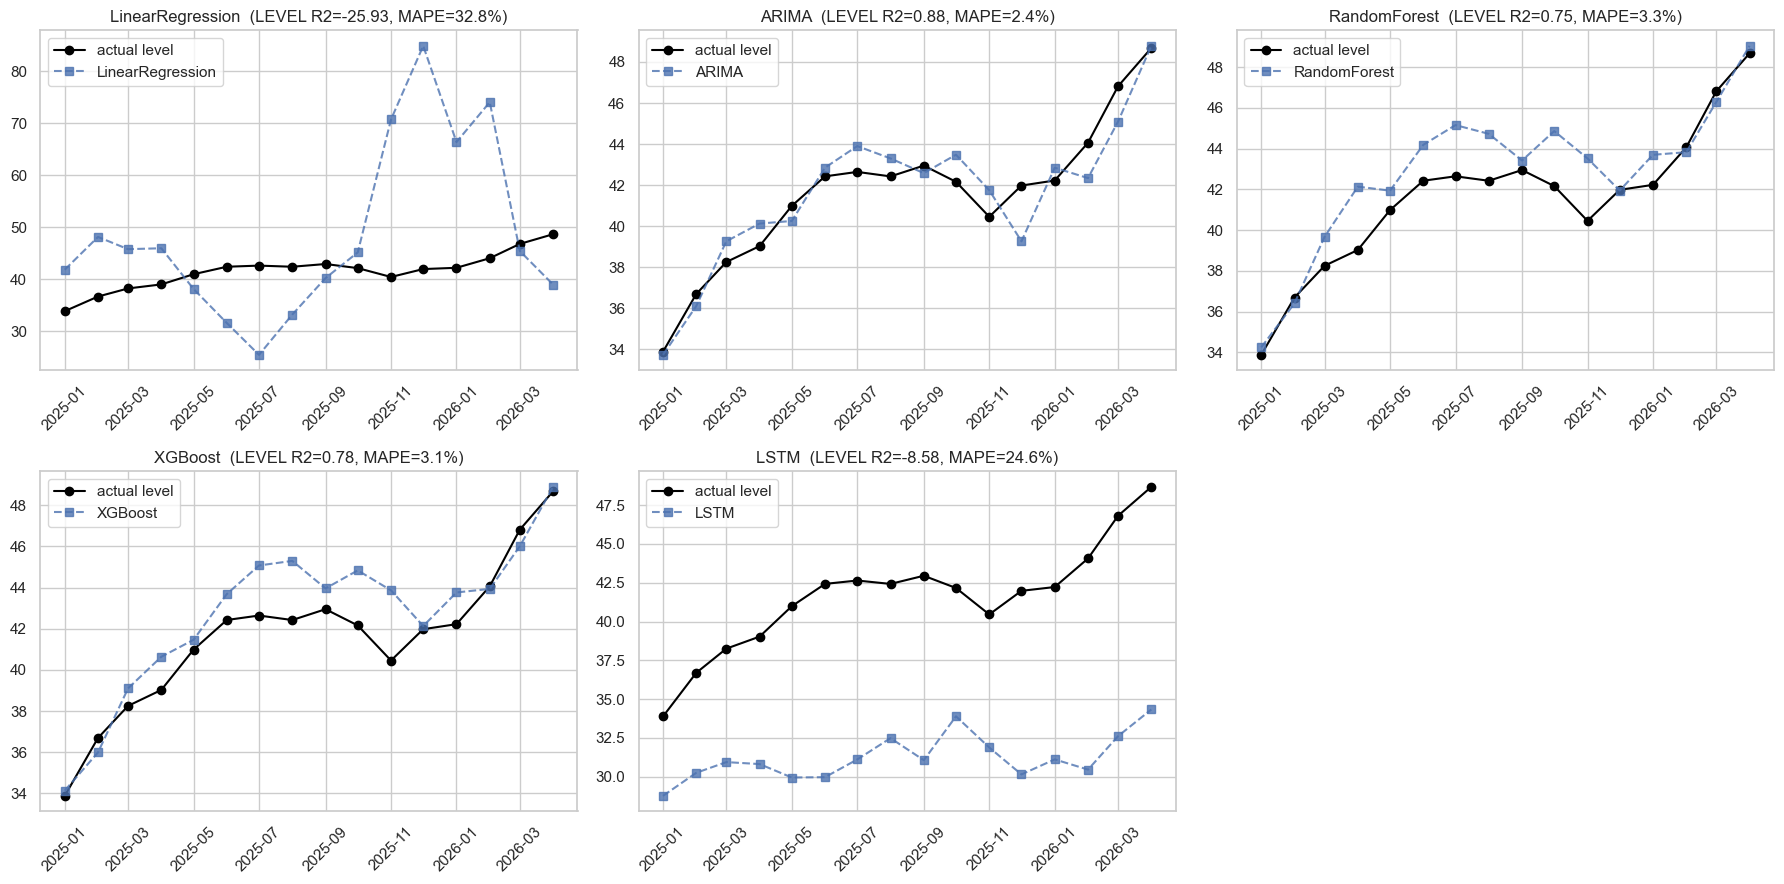

In [26]:
# predicted vs actual LEVEL on the test set
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, name in zip(axes.ravel(), results):
    ax.plot(pd.to_datetime(dates_test), level_true, "o-", color="black", label="actual level")
    ax.plot(pd.to_datetime(dates_test), pred_levels[name], "s--", alpha=0.8, label=name)
    ax.set_title(f"{name}  (LEVEL R2={results[name]['level']['R2']:.2f}, MAPE={results[name]['level']['MAPE']:.1f}%)")
    ax.tick_params(axis="x", rotation=45); ax.legend()
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()

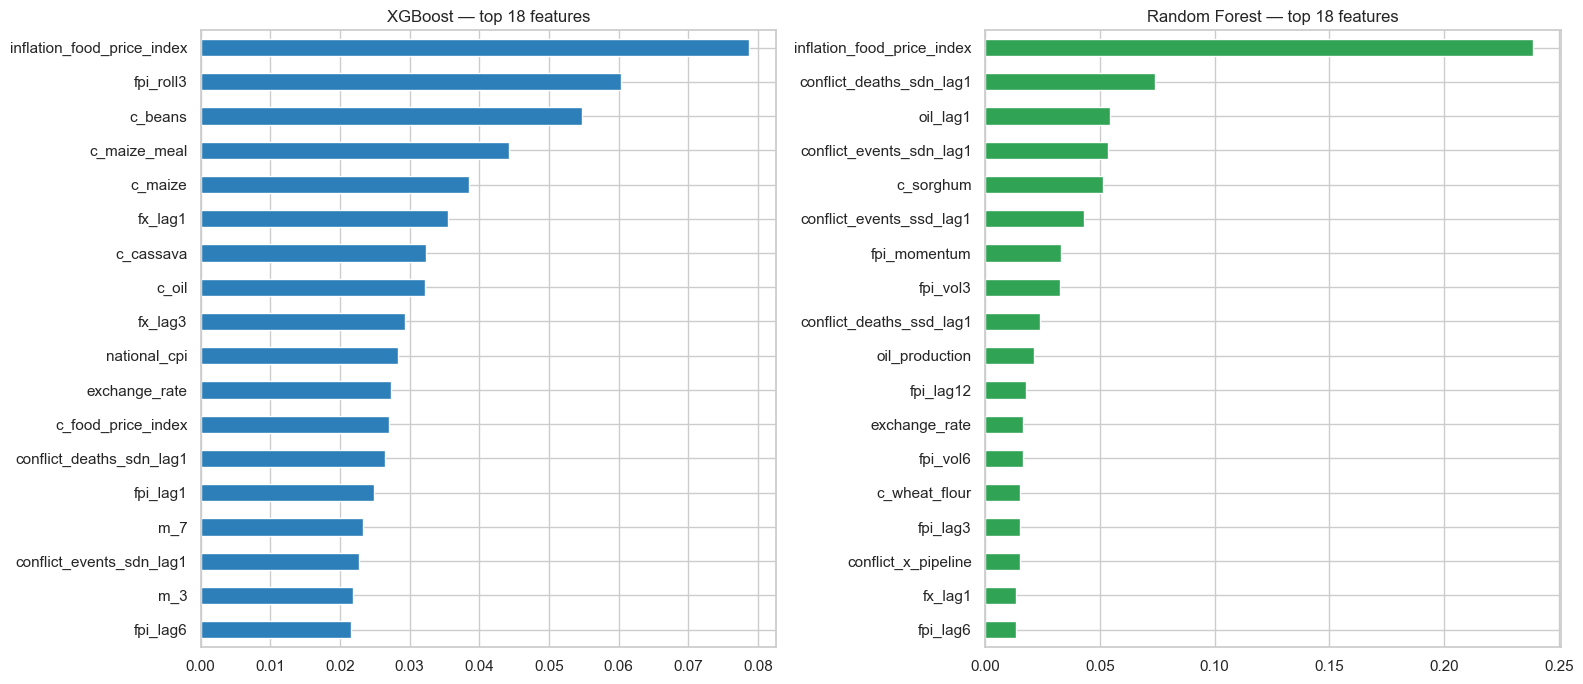

Importance of conflict / oil / exchange-rate features (do they matter now?):
                          XGBoost  RandomForest
exchange_rate              0.0273        0.0164
fx_lag1                    0.0355        0.0137
fx_lag3                    0.0294        0.0135
oil_production             0.0137        0.0214
oil_lag1                   0.0146        0.0542
conflict_events_ssd_lag1   0.0101        0.0429
conflict_deaths_ssd_lag1   0.0128        0.0240
conflict_events_sdn_lag1   0.0228        0.0535
conflict_deaths_sdn_lag1   0.0265        0.0740


In [27]:
# Do conflict / oil / exchange-rate features actually matter? (XGBoost & RF importances)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 7))
imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values().tail(18)
imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values().tail(18)
imp_xgb.plot.barh(ax=a1, title="XGBoost — top 18 features", color="#2c7fb8")
imp_rf.plot.barh(ax=a2, title="Random Forest — top 18 features", color="#31a354")
plt.tight_layout(); plt.show()

watch = ["exchange_rate","fx_lag1","fx_lag3","oil_production","oil_lag1",
         "conflict_events_ssd_lag1","conflict_deaths_ssd_lag1",
         "conflict_events_sdn_lag1","conflict_deaths_sdn_lag1"]
print("Importance of conflict / oil / exchange-rate features (do they matter now?):")
imp_all_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES)
imp_all_rf = pd.Series(rf.feature_importances_, index=FEATURES)
print(pd.DataFrame({"XGBoost": imp_all_xgb[watch], "RandomForest": imp_all_rf[watch]}).round(4).to_string())

## 13. Model Selection and Saving
Selection rule (unchanged): **R² ≥ 0.75 AND MAPE ≤ 15% on the reconstructed LEVEL**,
then lowest RMSE. The winner is saved to `ml-service/models/model.pkl` with everything
the API needs to reconstruct a level prediction.

In [28]:
level_for_pick = {n: r["level"] for n, r in results.items()}
qualifying = {n: m for n, m in level_for_pick.items() if m["R2"] >= 0.75 and m["MAPE"] <= 15.0}
if qualifying:
    winner = min(qualifying, key=lambda n: level_for_pick[n]["RMSE"])
    print(f"Winner meeting criteria (level-space): {winner}")
else:
    winner = min(level_for_pick, key=lambda n: level_for_pick[n]["RMSE"])
    print(f"WARNING: no model met R2>=0.75 AND MAPE<=15% on the level. "
          f"Falling back to lowest-RMSE: {winner}")
print("winner level metrics :", {k: round(v,4) for k,v in results[winner]['level'].items()})
print("winner change metrics:", {k: round(v,4) for k,v in results[winner]['change'].items()})

Winner meeting criteria (level-space): ARIMA
winner level metrics : {'RMSE': 1.1965, 'MAE': 1.0003, 'MAPE': 2.3894, 'R2': 0.8805}
winner change metrics: {'R2': 0.1933, 'MAPE': 72.8667, 'MAE': 0.024}


In [29]:
fitted = {"LinearRegression": lin, "RandomForest": rf, "XGBoost": xgb_model}
bundle = {
    "model_type": winner,
    "target": "log_change",                       # model predicts ln(next)-ln(this)
    "target_definition": "y = ln(next_month_index) - ln(this_month_index)",
    "reconstruction": "predicted_level = last_known_index * exp(predicted_log_change)",
    "feature_names": FEATURES,
    "uses_scaled_input": winner in ("LinearRegression", "LSTM"),
    "scaler": scaler if winner in ("LinearRegression", "LSTM") else None,
    "api_note": ("The API must build the 47-feature vector for the prediction month, "
                 "predict the log-change, then multiply the last known index by "
                 "exp(prediction) to get the level. ARIMA is the exception: it forecasts "
                 "the level directly via differencing."),
}
if winner == "ARIMA":
    bundle.update({"target": "level_via_differencing", "arima_order": list(best_order),
                   "model": "arima_refit_per_inference",
                   "reconstruction": "ARIMA forecasts the level directly; no exp() step."})
elif winner == "LSTM":
    kpath = MODELS_DIR / "model_lstm.keras"; lstm.save(kpath)
    bundle.update({"keras_path": str(kpath), "sequence_length": SEQ, "model": None})
else:
    bundle["model"] = fitted[winner]

# Also save the standalone tree models so XGBoost & RandomForest exist on disk.
joblib.dump(xgb_model, MODELS_DIR / "model_xgboost.pkl")
joblib.dump(rf, MODELS_DIR / "model_randomforest.pkl")
joblib.dump(bundle, MODELS_DIR / "model.pkl")
print("saved winner -> model.pkl ; also model_xgboost.pkl, model_randomforest.pkl")

saved winner -> model.pkl ; also model_xgboost.pkl, model_randomforest.pkl


In [30]:
version_name = f"v2_change_{winner.lower()}_{datetime.now():%Y%m%d}"
all_results = {n: {"level": {k: round(v,6) for k,v in r["level"].items()},
                   "change": {k: round(v,6) for k,v in r["change"].items()}}
               for n, r in results.items()}
metadata = {
    "version_name": version_name,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "target_reframing": ("v2 predicts the monthly LOG-CHANGE y=ln(next)-ln(this) using "
        "the full 47-feature set, then reconstructs the level as this*exp(y). This lets "
        "tree/NN models compete fairly: the change target is stationary, unlike the v1 "
        "level target where 100% of the test window lay above the training range."),
    "primary_metric_space": "level (reconstructed) — comparable to v1",
    "rmse": all_results[winner]["level"]["RMSE"],
    "mape": all_results[winner]["level"]["MAPE"],
    "r2_score": all_results[winner]["level"]["R2"],
    "winner": winner,
    "feature_names": FEATURES,
    "target_name": "y_log_change",
    "target_definition": "ln(next_month_index) - ln(this_month_index)",
    "reconstruction": "predicted_level = last_known_index * exp(predicted_log_change)",
    "training_data_range": {"start_date": str(pd.to_datetime(dates_train).min().date()),
                            "end_date": str(pd.to_datetime(dates_train).max().date())},
    "all_model_results": all_results,
    "v1_level_based_results": {
        "LinearRegression": {"RMSE":10.042,"MAE":9.015,"MAPE":21.37,"R2":-7.419},
        "ARIMA": {"RMSE":1.197,"MAE":1.000,"MAPE":2.39,"R2":0.880},
        "RandomForest": {"RMSE":14.292,"MAE":13.722,"MAPE":32.39,"R2":-16.053},
        "XGBoost": {"RMSE":33.499,"MAE":33.320,"MAPE":79.94,"R2":-92.685},
        "LSTM": {"RMSE":40.141,"MAE":40.005,"MAPE":96.16,"R2":-133.517}},
    "data_caveat": ("conflict (UCDP) and national CPI end 2024; oil ends Jan 2026 — "
                    "these features are forward/zero-filled across the 2025-2026 test window."),
}
with open(MODELS_DIR / "model_metadata.json", "w") as fh:
    json.dump(metadata, fh, indent=2)
print(json.dumps({k: metadata[k] for k in ["version_name","winner","rmse","mape","r2_score"]}, indent=2))

{
  "version_name": "v2_change_arima_20260618",
  "winner": "ARIMA",
  "rmse": 1.196516,
  "mape": 2.389444,
  "r2_score": 0.880478
}


In [31]:
print("FINAL COMPARISON — v2 (change-based), level-space sorted by RMSE\n")
print(res_df.round(4).to_string())
print(f"\nWINNER: {winner}")
print(f"  level-space : R2={results[winner]['level']['R2']:.4f}  MAPE={results[winner]['level']['MAPE']:.4f}%  "
      f"RMSE={results[winner]['level']['RMSE']:.4f}")
print(f"  change-space: R2={results[winner]['change']['R2']:.4f}")
print("\nArtifacts: model.pkl, model_metadata.json (v2), model_xgboost.pkl, model_randomforest.pkl")

FINAL COMPARISON — v2 (change-based), level-space sorted by RMSE

                  LEVEL_RMSE  LEVEL_MAE  LEVEL_MAPE  LEVEL_R2  CHANGE_R2  CHANGE_MAPE  CHANGE_MAE
model                                                                                            
ARIMA                 1.1965     1.0003      2.3894    0.8805     0.1933      72.8667      0.0240
XGBoost               1.6351     1.2752      3.0769    0.7768    -0.4402      90.0741      0.0301
RandomForest          1.7150     1.3486      3.2739    0.7544    -0.6194     100.8565      0.0319
LSTM                 10.7138    10.3671     24.5774   -8.5829   -82.4120     879.7860      0.2841
LinearRegression     17.9618    13.6329     32.8387  -25.9346  -118.1535     682.5898      0.2858

WINNER: ARIMA
  level-space : R2=0.8805  MAPE=2.3894%  RMSE=1.1965
  change-space: R2=0.1933

Artifacts: model.pkl, model_metadata.json (v2), model_xgboost.pkl, model_randomforest.pkl
